In [1]:
from pyrootmemo.models import Dram, Waldron, _DirectShear
from pyrootmemo.materials import MultipleRoots, Interface, Soil
from pyrootmemo.geometry import SoilProfile, FailureSurface
from pyrootmemo.helpers import units, Parameter, polarangles_to_unitvector

In [2]:
# generate some root data
roots = MultipleRoots(
    species = "test_species",
    diameter = Parameter([1, 2, 1, 3, 4, 5, 6,], 'mm'),
    tensile_strength = Parameter([40, 30, 40, 20, 10, 5, 20], 'MPa'),
    elastic_modulus = Parameter([100, 100, 100, 100, 100, 100, 100], 'MPa'),
    length = Parameter([1, 1, 1, 1, 1, 1, 1], 'm'),
    azimuth_angle = Parameter([0, 0, 0, 0, 0, 0, 0], 'deg'),
    elevation_angle = Parameter([0, 0, 0, 0, 0, 0, 0], 'deg')
    )
# soil--root interface
interface = Interface(
    shear_strength = Parameter(50, "kPa")
)
# generate some soil data
soil = Soil(
    "Sand",
    cohesion = Parameter(2, "kPa"),
    friction_angle = Parameter(30, "degrees"),
    unit_weight_bulk = Parameter(20, "kN/m^3")
)
# soil profile object
soil_profile = SoilProfile([soil], depth = Parameter([100], 'm'))
# failure surface object
failure_surface = FailureSurface(
    cross_sectional_area = Parameter(0.01, "m^2"),
    shear_zone_thickness = Parameter(2.0, "mm"),
    max_shear_zone_thickness = Parameter(25.0, "mm"),
    depth = Parameter(1.0, "m"),
    azimuth_angle = Parameter(0.0, 'deg'),
    elevation_angle = Parameter(10.0, 'deg')
)

In [3]:
# Create DRAM object
dram = Dram(roots, interface, soil_profile, failure_surface)

c:\Users\gjm36\AppData\Local\miniforge3\envs\rrmm\Lib\site-packages\matplotlib\cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


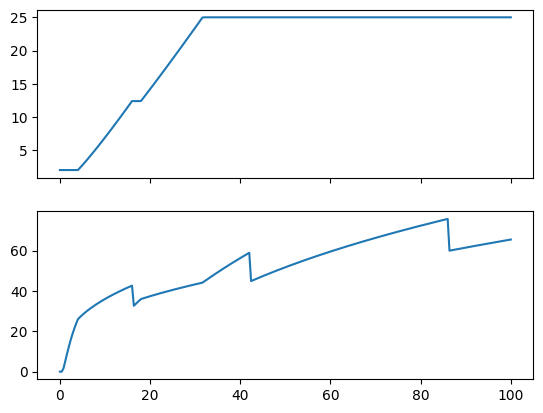

In [4]:
res = dram.calc_reinforcement(Parameter(100, 'mm'))
import matplotlib.pyplot as plt
#print(res)
fig, axs = plt.subplots(2, 1, sharex = True)
axs[0].plot(res['displacement'], res['shear_zone_thickness'])
axs[1].plot(res['displacement'], res['reinforcement'])

In [7]:
print(dram.calc_peak_reinforcement())

{'displacement': <Quantity(86.0495577, 'millimeter')>, 'reinforcement': <Quantity(75.6806936, 'kilopascal')>}


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Shear displacement [mm]', ylabel='Reinforcement [kPa]'>)

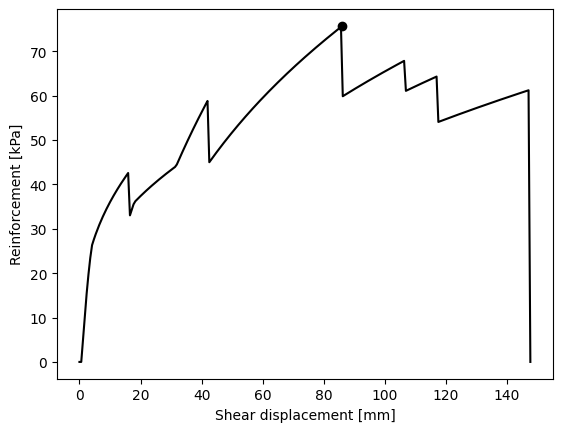

In [8]:
dram.plot()